# Q4 — Destilação de conhecimento (professor → aluno)

**Grupo 2:** Francisco Cosme Monteiro Xavier, Heitor Andrade Moura, Isaac Augusto Santana Brito e João Pedro Monteiro da Silva Barros

- **Objetivo:** transferir capacidade de um modelo grande (professor) para um menor (aluno) usando dados sintéticos.
- **Método:** professor responde prompts → aluno faz SFT nessas respostas → compara a acurácia do aluno antes/depois e contra o professor.
- **Modelos:** professor `Qwen3-4B` (4-bit, modelo do grupo) → aluno `Qwen3-0.6B` (gap maior = transferência visível). Dados: DOM-PI.
- **Avaliação (sem vazamento):** o benchmark conceitual é dividido em metade-treino (professor gera dados)
  e metade-avaliação **disjunta**; mede-se o aluno só na metade de avaliação + as 20 **factuais** de controle.
  Assim o ganho conceitual é transferência real, não memorização. Mede professor, aluno-antes e aluno-depois.
- **Saída:** aluno em `heitor-am/qwen3-0.6b-dompi-distill`.

## Passo a passo
1. Carrega o professor (Qwen3-4B).
2. Divide o benchmark conceitual em metade-treino (disjunta) e metade-avaliação.
3. O professor gera os dados sintéticos sobre a metade de treino.
4. Avalia o professor; carrega o aluno (Qwen3-0.6B) e avalia ANTES.
5. Treina o aluno (SFT/QLoRA) nos dados do professor e avalia DEPOIS: conceitual disjunto + factual (controle).

### Setup — montar o Google Drive e entrar na pasta (persiste os resultados)

In [1]:
# Necessário p/ os results_qN.json caírem no Drive (não no /content efêmero). Fora do Colab, pule.
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ufpi/topics-in-ai/final-project

Mounted at /content/drive
/content/drive/MyDrive/ufpi/topics-in-ai/final-project


### Instalação

In [2]:
!pip -q install -U transformers trl peft bitsandbytes accelerate datasets
!pip -q install -U pyarrow    # compat com datasets; se der "IpcReadOptions size changed", REINICIE a sessao e rode de novo
!pip -q uninstall -y torchao   # evita conflito de versão (PEFT exige torchao>=0.16; não usamos)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.8/838.8 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 23.2 MB/s eta 0:00:00


### Login no Hugging Face (token WRITE; NÃO escreva no código)

In [3]:
from huggingface_hub import notebook_login
notebook_login()

### Carregar PROFESSOR (Qwen3-4B em 4-bit)

In [4]:
import os, torch, json, gc
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
MODE = "oficial"   # "smoke" (prof 1.7B → aluno 0.6B, valida rápido) ou "oficial" (4B → 0.6B)
TEACHER_ID, STUDENT_ID = {"smoke":   ("Qwen/Qwen3-1.7B", "Qwen/Qwen3-0.6B"),
                          "oficial": ("Qwen/Qwen3-4B",   "Qwen/Qwen3-0.6B")}[MODE]
print(f"MODE={MODE} | professor={TEACHER_ID} | aluno={STUDENT_ID}")
DTYPE = "fp16"   # "fp16" (T4, recomendado) ou "float32" (mais memoria; use so se fp16/bf16 quebrar)
_CDT = torch.float16 if DTYPE == "fp16" else torch.float32
_FP16 = (DTYPE == "fp16")
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype=_CDT, bnb_4bit_use_double_quant=True)
tok = AutoTokenizer.from_pretrained(TEACHER_ID)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
teacher = AutoModelForCausalLM.from_pretrained(TEACHER_ID, quantization_config=bnb, device_map="auto").eval()

def gerar(m, pergunta, max_new=200):
    enc = tok.apply_chat_template([{"role": "user", "content": pergunta}], tokenize=True,
            add_generation_prompt=True, enable_thinking=False, return_tensors="pt", return_dict=True).to(m.device)
    out = m.generate(**enc, max_new_tokens=max_new, do_sample=False, pad_token_id=tok.pad_token_id)
    return tok.decode(out[0, enc["input_ids"].shape[1]:], skip_special_tokens=True).strip()

MODE=oficial | professor=Qwen/Qwen3-4B | aluno=Qwen/Qwen3-0.6B


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

### Dataset sintético SEM vazamento — professor responde tópicos DISJUNTOS da avaliação

In [6]:
# Correção de contaminação (train/test leakage): o benchmark conceitual é dividido em duas metades.
# O professor gera dados de treino sobre a metade de TREINO; o aluno é avaliado na metade de AVALIAÇÃO
# (disjunta) — nenhum item de treino reaparece no teste. Assim o ganho conceitual mede transferência
# de verdade, não memorização do próprio benchmark.
import json
_bench = json.load(open("benchmark_distill_mcq.json"))
_conc = _bench["conceitual"]
_meio = len(_conc) // 2
conc_treino, mcq_conceitual = _conc[:_meio], _conc[_meio:]    # treino (professor) x avaliação (disjunta)
mcq_factual = _bench["factual"]                               # controle: fato local (professor não sabe)
print(f"conceitual: {len(conc_treino)} p/ treino sintético | {len(mcq_conceitual)} p/ avaliação (disjuntos) | factual: {len(mcq_factual)}")

# Interruptor de reaproveitamento: se o adapter do aluno já existe no HF, pula geração sintética E treino.
RETRAIN = True            # True = gera dados + treina do zero; False = carrega o aluno já publicado
_dsize = STUDENT_ID.split("-")[-1].lower()
REPO = f"heitor-am/qwen3-{_dsize}-dompi-distill"
def _existe_hf(repo):
    try:
        from huggingface_hub import repo_exists; return repo_exists(repo)
    except Exception:
        return False
PULAR_TREINO = (not RETRAIN) and _existe_hf(REPO)

if PULAR_TREINO:
    sintetico = []
    print("Adapter do aluno já no HF — geração sintética e treino serão pulados:", REPO)
else:
    prompts = ["Explique de forma didática: " + it["q"] for it in conc_treino]
    sintetico = [{"instruction": p, "input": "", "output": gerar(teacher, p)} for p in prompts]
    json.dump(sintetico, open("sintetico.json", "w"), ensure_ascii=False, indent=2)
    print("exemplos sintéticos:", len(sintetico))

conceitual: 41 p/ treino sintético | 41 p/ avaliação (disjuntos) | factual: 20


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


exemplos sintéticos: 41


### Funções de avaliação MCQ (conceitual disjunto da avaliação + factual controle)

In [7]:
@torch.no_grad()
def acuracia_mcq(m, itens):
    ok = 0
    for it in itens:
        base = tok.apply_chat_template(
            [{"role":"user","content":it["q"]+"\nResponda apenas com a alternativa correta."}],
            tokenize=False, add_generation_prompt=True, enable_thinking=False)
        bid = tok(base, return_tensors="pt").input_ids.to(m.device)
        best, bs = 0, -1e9
        for i, op in enumerate(it["options"]):
            oid = tok(" "+op, return_tensors="pt", add_special_tokens=False).input_ids.to(m.device)
            full = torch.cat([bid, oid], dim=1); lab = full.clone(); lab[:, :bid.shape[1]] = -100
            s = -m(full, labels=lab).loss.item()
            if s > bs: best, bs = i, s
        ok += (best == it["answer"])
    return ok/len(itens)
def avaliar(m):
    return {"conceitual": round(acuracia_mcq(m, mcq_conceitual), 3),
            "factual":    round(acuracia_mcq(m, mcq_factual), 3)}
acc_prof = avaliar(teacher)
print("PROFESSOR:", acc_prof)
del teacher; gc.collect(); torch.cuda.empty_cache()      # libera memória do professor

PROFESSOR: {'conceitual': 0.732, 'factual': 0.25}


### Carregar ALUNO + avaliar ANTES

In [8]:
student = AutoModelForCausalLM.from_pretrained(STUDENT_ID, quantization_config=bnb, device_map="auto")
acc_aluno_antes = avaliar(student)
print("ALUNO (antes):", acc_aluno_antes)

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

ALUNO (antes): {'conceitual': 0.659, 'factual': 0.2}


### Treinar o aluno OU carregar o adapter já publicado no HF (evita re-treino)

In [12]:
from datasets import Dataset
from peft import LoraConfig, PeftModel
from trl import SFTTrainer, SFTConfig
if PULAR_TREINO:
    aluno_final = PeftModel.from_pretrained(student, REPO).eval()   # reaproveita o treino persistido
    print("Aluno carregado do HF (treino pulado):", REPO)
else:
    def fmt(ex):
        return {"text": tok.apply_chat_template(
            [{"role":"user","content":ex["instruction"]},{"role":"assistant","content":ex["output"]}],
            tokenize=False, enable_thinking=False)}
    ds = Dataset.from_list(sintetico).map(fmt)
    lora = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
                      target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"])
    cfg = SFTConfig(output_dir="/content/qwen3-distill", per_device_train_batch_size=1, gradient_accumulation_steps=8,
                    num_train_epochs=2, learning_rate=2e-4, fp16=False, bf16=False, logging_steps=10,
                    max_length=1024, dataset_text_field="text",
                    gradient_checkpointing=True, gradient_checkpointing_kwargs={"use_reentrant": False},
                    optim="paged_adamw_8bit", report_to="none")
    trainer = SFTTrainer(model=student, train_dataset=ds, args=cfg, peft_config=lora)
    trainer.train()
    aluno_final = trainer.model

Map:   0%|          | 0/41 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Adding EOS to train dataset:   0%|          | 0/41 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/41 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/41 [00:00<?, ? examples/s]

Step,Training Loss
10,1.388112


### Avaliar DEPOIS + persistir

In [13]:
acc_aluno_depois = avaliar(aluno_final)
print("============== RESULTADO Q4 — acurácia MCQ ==============")
print(f"{'':14}| conceitual | factual")
print(f"Professor     |   {acc_prof['conceitual']:.3f}    |  {acc_prof['factual']:.3f}")
print(f"Aluno  ANTES  |   {acc_aluno_antes['conceitual']:.3f}    |  {acc_aluno_antes['factual']:.3f}")
print(f"Aluno  DEPOIS |   {acc_aluno_depois['conceitual']:.3f}    |  {acc_aluno_depois['factual']:.3f}")
print("(esperado: conceitual SOBE com a destilação; factual ~acaso — fato local exige RAG)")
if not PULAR_TREINO:
    aluno_final.push_to_hub(REPO); tok.push_to_hub(REPO)
    print("salvo em", f"https://huggingface.co/{REPO}")
else:
    print("treino pulado — adapter já no HF:", REPO)
json.dump({"questao":"Q4-distill","modo":MODE,"professor":TEACHER_ID,"aluno":STUDENT_ID,
           "prof":acc_prof,"aluno_antes":acc_aluno_antes,"aluno_depois":acc_aluno_depois},
          open("results_q4.json","w"), ensure_ascii=False, indent=2)

============== RESULTADO Q4 — acurácia MCQ ==============
              | conceitual | factual
Professor     |   0.732    |  0.250
Aluno  ANTES  |   0.659    |  0.200
Aluno  DEPOIS |   0.659    |  0.300
(esperado: conceitual SOBE com a destilação; factual ~acaso — fato local exige RAG)


README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   3%|3         |  626kB / 20.2MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp2oz1jq38/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

No files have been modified since last commit. Skipping to prevent empty commit.


salvo em https://huggingface.co/heitor-am/qwen3-0.6b-dompi-distill


## LLMs comumente usados em destilação (levantamento)

Destilação de conhecimento (Hinton et al., 2015) transfere o comportamento de um modelo grande
(**professor**) para um menor (**aluno**). O que se costuma usar:

- **Professores (grandes/capazes):** via API — GPT-4/4o, Claude, Gemini (geram dados sintéticos);
  open-weights — Llama 3.1-70B/405B, Qwen2.5/3-32B/72B, DeepSeek-V3/R1, Mixtral.
- **Alunos (pequenos/implantáveis):** Llama 3.2-1B/3B, Qwen3-0.6B/1.7B/4B, Gemma-2-2B, Phi-3-mini,
  TinyLlama, SmolLM.
- **Casos notórios:** Alpaca/Vicuna (destilados de GPT), Zephyr (dSFT+dDPO), Orca (explicações do
  professor), **DeepSeek-R1-Distill** (raciocínio destilado para Qwen/Llama pequenos), Gemini-Nano.

**Tipos de destilação:**
- **Black-box / dados sintéticos (usada aqui):** o professor gera respostas e o aluno faz SFT nelas;
  precisa só das saídas — funciona até via API.
- **White-box / logits (KD clássica):** o aluno imita a distribuição de probabilidade do professor
  (KL divergence); exige acesso aos logits.

Neste trabalho: professor **Qwen3-4B** → aluno **Qwen3-0.6B** (mesma família), **black-box** por dados sintéticos.

## Conclusão
- Houve **transferência** se, no benchmark **conceitual**, o **aluno DEPOIS > aluno ANTES**,
  aproximando-se do **professor** — é o que a destilação consegue mover (competência geral).
- O benchmark **factual** funciona como **controle**: tende a ficar no acaso (~25%) antes e depois,
  porque o professor genérico também não conhece os fatos locais do DOM-PI — logo não há o que
  transferir. O gap maior (4B → 0.6B) torna o ganho conceitual mais visível.
- **Leitura para o relatório:** destilação transfere *como responder*, não *fatos pontuais*. Para
  fatos locais, gere os dados sintéticos com o professor + **RAG** (contexto recuperado), ou use o
  RAG diretamente na inferência (Q5). Reforça a tese "cada técnica resolve uma coisa diferente".

### Gráfico do resultado — transferência conceitual vs factual

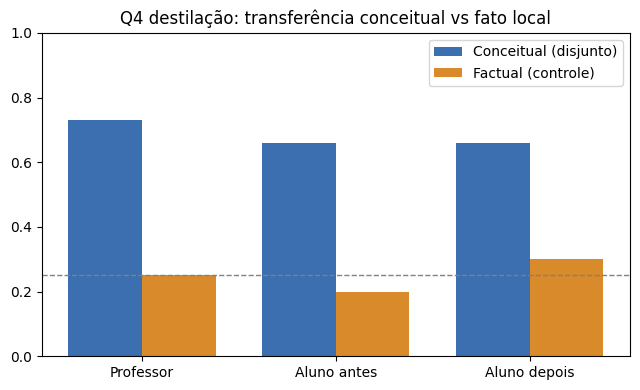

In [14]:
import matplotlib.pyplot as plt, numpy as np
grp = ["Professor", "Aluno antes", "Aluno depois"]
conc = [acc_prof["conceitual"], acc_aluno_antes["conceitual"], acc_aluno_depois["conceitual"]]
fac = [acc_prof["factual"], acc_aluno_antes["factual"], acc_aluno_depois["factual"]]
x = np.arange(3); w = 0.38
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(x - w/2, conc, w, label="Conceitual (disjunto)", color="#3b6fb0")
ax.bar(x + w/2, fac, w, label="Factual (controle)", color="#d98a2b")
ax.axhline(0.25, ls="--", c="gray", lw=1); ax.set_ylim(0, 1); ax.set_xticks(x); ax.set_xticklabels(grp); ax.legend()
ax.set_title("Q4 destilação: transferência conceitual vs fato local")
plt.tight_layout(); plt.show()